# EDA — MovieLens 100K
# Hệ Gợi Ý Phím 

| Thông tin | Giá trị |
|---|---|
| Dataset | MovieLens 100K |
| Users | 943 |
| Movies | 1 682 |
| Ratings | 100 000 |
| Scale | 1–5 (int) |
| Sparsity | ~93.7% |

In [24]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
    print('Running in Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

if IN_COLAB:
    # TODO: thay YOUR_USERNAME/YOUR_REPO bang GitHub repo cua ban
    REPO_URL = 'https://github.com/YOUR_USERNAME/YOUR_REPO'
    REPO_DIR = 'movie-rec-btl'
    if not os.path.exists(REPO_DIR):
        os.system(f'git clone {REPO_URL} {REPO_DIR}')
    sys.path.insert(0, REPO_DIR)
    BASE_DIR = REPO_DIR
else:
    BASE_DIR = os.path.abspath('..')
    if BASE_DIR not in sys.path:
        sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, 'data', 'ml-100k')
FIG_DIR  = os.path.join(BASE_DIR, 'reports', 'figures')
FEAT_DIR = os.path.join(BASE_DIR, 'features')

for d in [FIG_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'FIG_DIR  : {FIG_DIR}')
print(f'FEAT_DIR : {FEAT_DIR}')

Running locally
BASE_DIR : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl
DATA_DIR : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\data\ml-100k
FIG_DIR  : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\reports\figures
FEAT_DIR : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features


In [25]:
import importlib, subprocess

REQUIRED = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
}
for mod, pkg in REQUIRED.items():
    if importlib.util.find_spec(mod) is None:
        print(f'Installing {pkg}...')
        subprocess.run(['pip', 'install', '-q', pkg], check=True)

print('All libraries ready.')

All libraries ready.


In [26]:
import urllib.request, zipfile

ML_URL   = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
ZIP_PATH = os.path.join(BASE_DIR, 'data', 'ml-100k.zip')

if not os.path.isdir(DATA_DIR):
    os.makedirs(os.path.join(BASE_DIR, 'data'), exist_ok=True)
    if not os.path.isfile(ZIP_PATH):
        print('Downloading ml-100k.zip ...')
        urllib.request.urlretrieve(ML_URL, ZIP_PATH)
        print('Download done.')
    print('Extracting ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(os.path.join(BASE_DIR, 'data'))
    print(f'Extracted to {DATA_DIR}')
else:
    print(f'Data already at {DATA_DIR}')

Data already at c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\data\ml-100k


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130})

from modules.utils.data_loader import load_all, GENRE_COLS
from modules.utils.split       import train_test_split
from modules.utils.features    import build_and_save_all, build_interaction_matrix

print('Imports OK')

Imports OK


In [28]:
ratings, movies, users = load_all(DATA_DIR)

print('\n-- ratings (head 3) --')
print(ratings.head(3).to_string())
print('\n-- movies (head 3) --')
print(movies[['movie_id', 'title', 'year'] + GENRE_COLS[:5]].head(3).to_string())
print('\n-- users (head 3) --')
print(users.head(3).to_string())

Ratings : 100,000 rows  |  users=943, movies=1682
Movies  :   1,682 rows  |  genres=19
Users   :     943 rows  |  occupations=21

-- ratings (head 3) --
   user_id  movie_id  rating  timestamp
0      196       242     3.0  881250949
1      186       302     3.0  891717742
2       22       377     1.0  878887116

-- movies (head 3) --
   movie_id              title    year  unknown  Action  Adventure  Animation  Children's
0         1   Toy Story (1995)  1995.0        0       0          0          1           1
1         2   GoldenEye (1995)  1995.0        0       1          1          0           0
2         3  Four Rooms (1995)  1995.0        0       0          0          0           0

-- users (head 3) --
   user_id  age gender  occupation    zip
0        1   24      M  technician  85711
1        2   53      F       other  94043
2        3   23      M      writer  32067


In [29]:
train_df, test_df = train_test_split(ratings, test_ratio=0.2, random_state=42)

N_U, N_M   = 943, 1682
global_mean = ratings['rating'].mean()
print(f'train : {train_df.shape}  |  test : {test_df.shape}')
print(f'Global mean rating: {global_mean:.4f}')

Train: 80,367 ratings (80.4%)
Test : 19,633 ratings (19.6%)
Users in train: 943 | test: 943
train : (80367, 4)  |  test : (19633, 4)
Global mean rating: 3.5299


---
## 1. Tổng quan Dataset

In [30]:
print('=== RATINGS ===')
print(f'  Shape        : {ratings.shape}')
print(f'  Missing      : {ratings.isnull().sum().sum()}')
print(f'  Rating range : {int(ratings["rating"].min())} -- {int(ratings["rating"].max())}')

print('\n=== MOVIES ===')
print(f'  Shape         : {movies.shape}')
total_tags = int(movies[GENRE_COLS].sum().sum())
print(f'  Total genre tags : {total_tags}  (avg {total_tags/len(movies):.2f}/movie)')

print('\n=== USERS ===')
print(f'  Shape         : {users.shape}')
print(f'  Age range     : {users["age"].min()} -- {users["age"].max()}')
print(f'  Occupations   : {users["occupation"].nunique()}')
print(f'  Gender dist   : {users["gender"].value_counts().to_dict()}')

print('\n=== SPARSITY ===')
total_cells = N_U * N_M
sparsity = 1 - len(ratings) / total_cells
print(f'  {N_U} users x {N_M} movies = {total_cells:,} cells')
print(f'  Rated cells : {len(ratings):,}  ({1-sparsity:.2%})')
print(f'  Sparsity    : {sparsity:.4%}')

=== RATINGS ===
  Shape        : (100000, 4)
  Missing      : 0
  Rating range : 1 -- 5

=== MOVIES ===
  Shape         : (1682, 22)
  Total genre tags : 2893  (avg 1.72/movie)

=== USERS ===
  Shape         : (943, 5)
  Age range     : 7 -- 73
  Occupations   : 21
  Gender dist   : {'M': 670, 'F': 273}

=== SPARSITY ===
  943 users x 1682 movies = 1,586,126 cells
  Rated cells : 100,000  (6.30%)
  Sparsity    : 93.6953%


---
## 2. Phân phối Rating

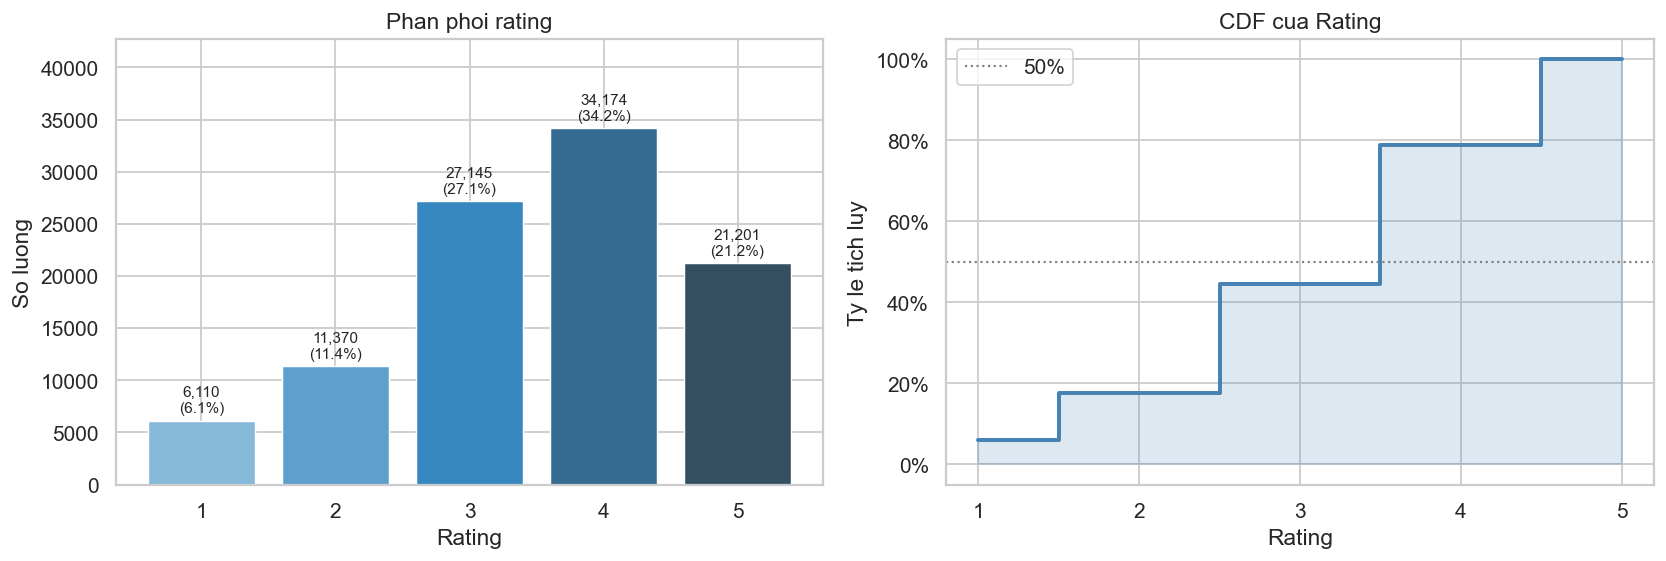

Mean=3.5299  Median=4.0  Std=1.1257  Skew=-0.5101


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rc = ratings['rating'].value_counts().sort_index()
colors_bar = sns.color_palette('Blues_d', 5)
bars = axes[0].bar(rc.index, rc.values, color=colors_bar, edgecolor='white', lw=0.8)
for bar, (r, c) in zip(bars, zip(rc.index, rc.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, c + 500,
                 f'{c:,}\n({c/len(ratings):.1%})',
                 ha='center', va='bottom', fontsize=8.5)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('So luong')
axes[0].set_title('Phan phoi rating')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0, rc.max() * 1.25)

cumulative = rc.cumsum() / len(ratings)
axes[1].step(rc.index, cumulative.values, color='steelblue', lw=2.2, where='mid')
axes[1].fill_between(rc.index, cumulative.values, step='mid', alpha=0.18, color='steelblue')
axes[1].axhline(0.5, color='gray', linestyle=':', lw=1.2, label='50%')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Ty le tich luy')
axes[1].set_title('CDF cua Rating')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_rating_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean={ratings["rating"].mean():.4f}  Median={ratings["rating"].median():.1f}  '
      f'Std={ratings["rating"].std():.4f}  Skew={ratings["rating"].skew():.4f}')

---
## 3. Hoạt động Người dùng (User Activity)

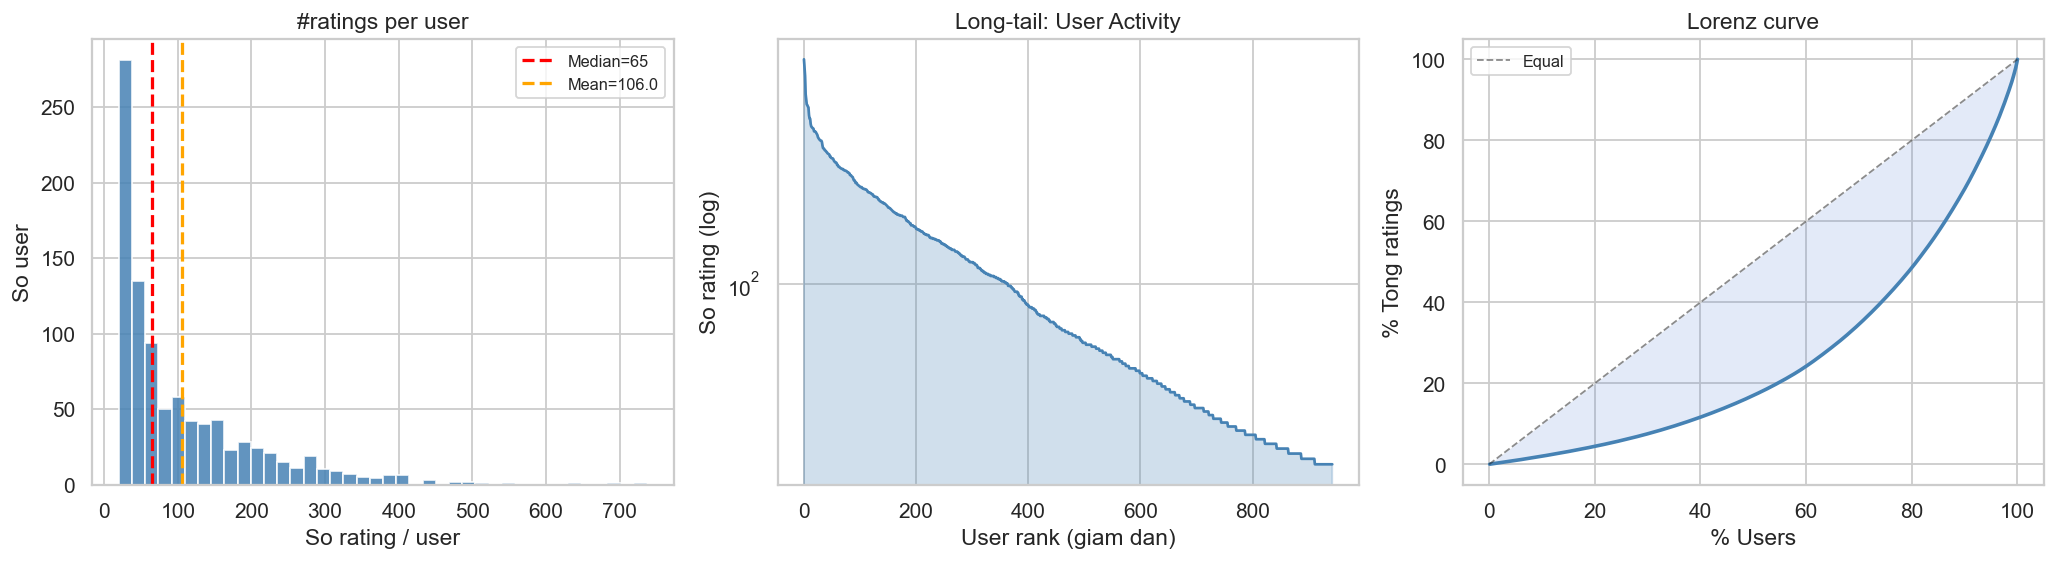

Min=20  Max=737  Median=65  Mean=106.0
Top 10% users dong gop: 31.9% tong ratings


In [32]:
user_act = ratings.groupby('user_id')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(user_act.values, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(user_act.median(), color='red', linestyle='--', lw=1.8,
                label=f'Median={user_act.median():.0f}')
axes[0].axvline(user_act.mean(), color='orange', linestyle='--', lw=1.8,
                label=f'Mean={user_act.mean():.1f}')
axes[0].set_xlabel('So rating / user')
axes[0].set_ylabel('So user')
axes[0].set_title('#ratings per user')
axes[0].legend(fontsize=9)

axes[1].plot(range(len(user_act)), user_act.values, color='steelblue', lw=1.5)
axes[1].fill_between(range(len(user_act)), user_act.values, alpha=0.25, color='steelblue')
axes[1].set_xlabel('User rank (giam dan)')
axes[1].set_ylabel('So rating (log)')
axes[1].set_title('Long-tail: User Activity')
axes[1].set_yscale('log')

sorted_asc  = user_act.sort_values()
cum_users   = np.arange(1, len(sorted_asc)+1) / len(sorted_asc)
cum_ratings = sorted_asc.cumsum().values / sorted_asc.sum()
axes[2].plot(cum_users * 100, cum_ratings * 100, color='steelblue', lw=2)
axes[2].plot([0, 100], [0, 100], 'k--', lw=1, alpha=0.5, label='Equal')
axes[2].fill_between(cum_users * 100, cum_ratings * 100, cum_users * 100, alpha=0.15)
axes[2].set_xlabel('% Users')
axes[2].set_ylabel('% Tong ratings')
axes[2].set_title('Lorenz curve')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_user_activity.png'), dpi=150, bbox_inches='tight')
plt.show()

top10_pct = user_act.nlargest(int(0.1 * len(user_act))).sum() / len(ratings)
print(f'Min={user_act.min()}  Max={user_act.max()}  '
      f'Median={user_act.median():.0f}  Mean={user_act.mean():.1f}')
print(f'Top 10% users dong gop: {top10_pct:.1%} tong ratings')

---
## 4. Độ phổ biến Phím (Movie Popularity)

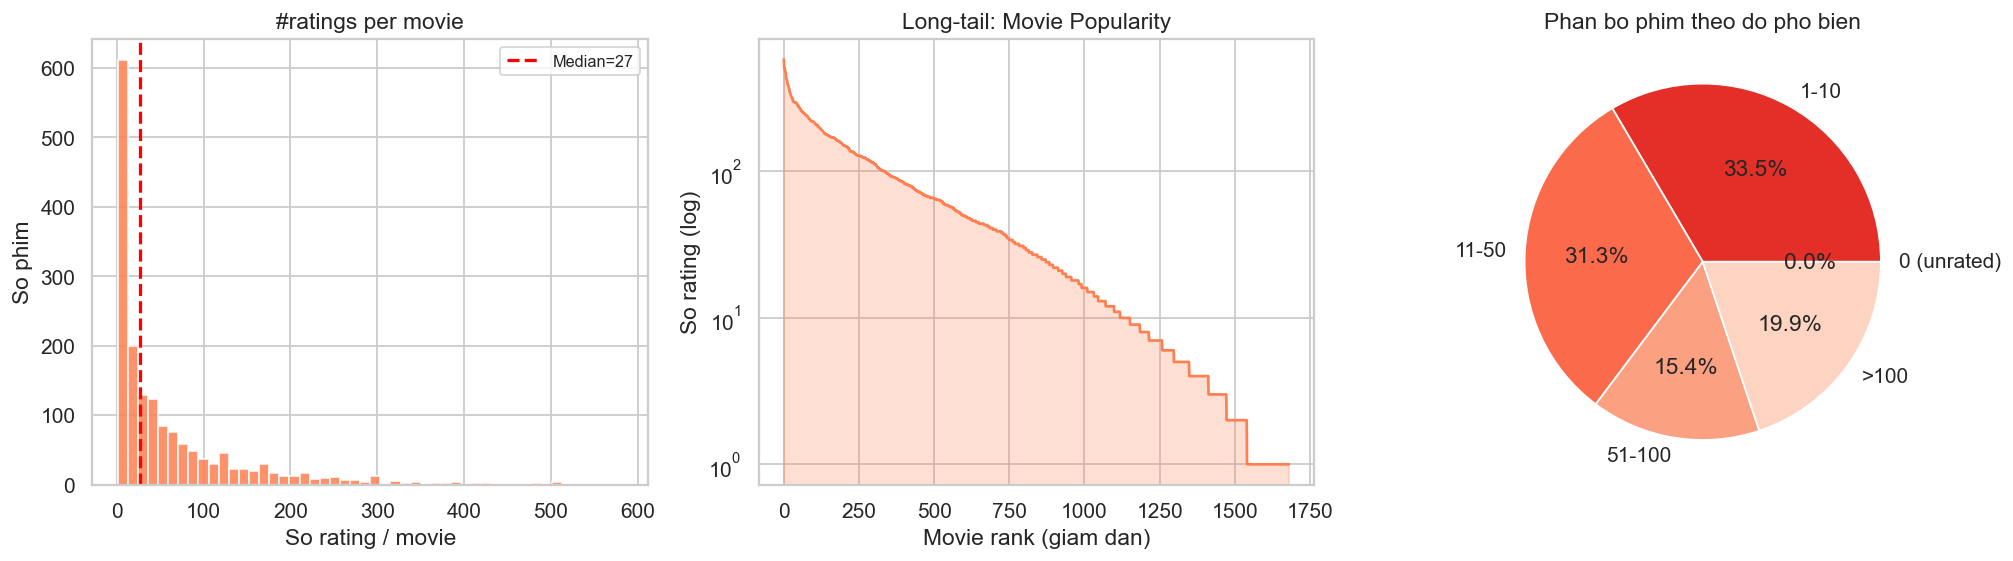

Phim chua duoc rate (cold-start): 0  (0.0%)

Top 5:
                    title  num_ratings  avg_rating
         Star Wars (1977)          583    4.358491
           Contact (1997)          509    3.803536
             Fargo (1996)          508    4.155512
Return of the Jedi (1983)          507    4.007890
         Liar Liar (1997)          485    3.156701


In [33]:
movie_pop = ratings.groupby('movie_id')['rating'].agg(['count', 'mean']).reset_index()
movie_pop.columns = ['movie_id', 'num_ratings', 'avg_rating']
all_ids = pd.DataFrame({'movie_id': range(1, N_M + 1)})
movie_pop_full = all_ids.merge(movie_pop, on='movie_id', how='left').fillna(0)
pop_sorted = movie_pop.sort_values('num_ratings', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(movie_pop['num_ratings'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(movie_pop['num_ratings'].median(), color='red', linestyle='--', lw=1.8,
                label=f'Median={movie_pop["num_ratings"].median():.0f}')
axes[0].set_xlabel('So rating / movie')
axes[0].set_ylabel('So phim')
axes[0].set_title('#ratings per movie')
axes[0].legend(fontsize=9)

axes[1].plot(range(len(pop_sorted)), pop_sorted['num_ratings'].values, color='coral', lw=1.5)
axes[1].fill_between(range(len(pop_sorted)), pop_sorted['num_ratings'].values,
                     alpha=0.25, color='coral')
axes[1].set_xlabel('Movie rank (giam dan)')
axes[1].set_ylabel('So rating (log)')
axes[1].set_title('Long-tail: Movie Popularity')
axes[1].set_yscale('log')

bins_p   = [-1, 0, 10, 50, 100, movie_pop_full['num_ratings'].max() + 1]
labels_p = ['0 (unrated)', '1-10', '11-50', '51-100', '>100']
tier_counts = pd.cut(movie_pop_full['num_ratings'], bins=bins_p,
                     labels=labels_p).value_counts().sort_index()
axes[2].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Reds_r', len(tier_counts)))
axes[2].set_title('Phan bo phim theo do pho bien')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_movie_popularity.png'), dpi=150, bbox_inches='tight')
plt.show()

n_cold = (movie_pop_full['num_ratings'] == 0).sum()
print(f'Phim chua duoc rate (cold-start): {n_cold}  ({n_cold/N_M:.1%})')
top5 = pop_sorted.head(5).merge(movies[['movie_id', 'title']], on='movie_id')
print('\nTop 5:')
print(top5[['title', 'num_ratings', 'avg_rating']].to_string(index=False))

---
## 5. Phân tích Thể loại (Genre)

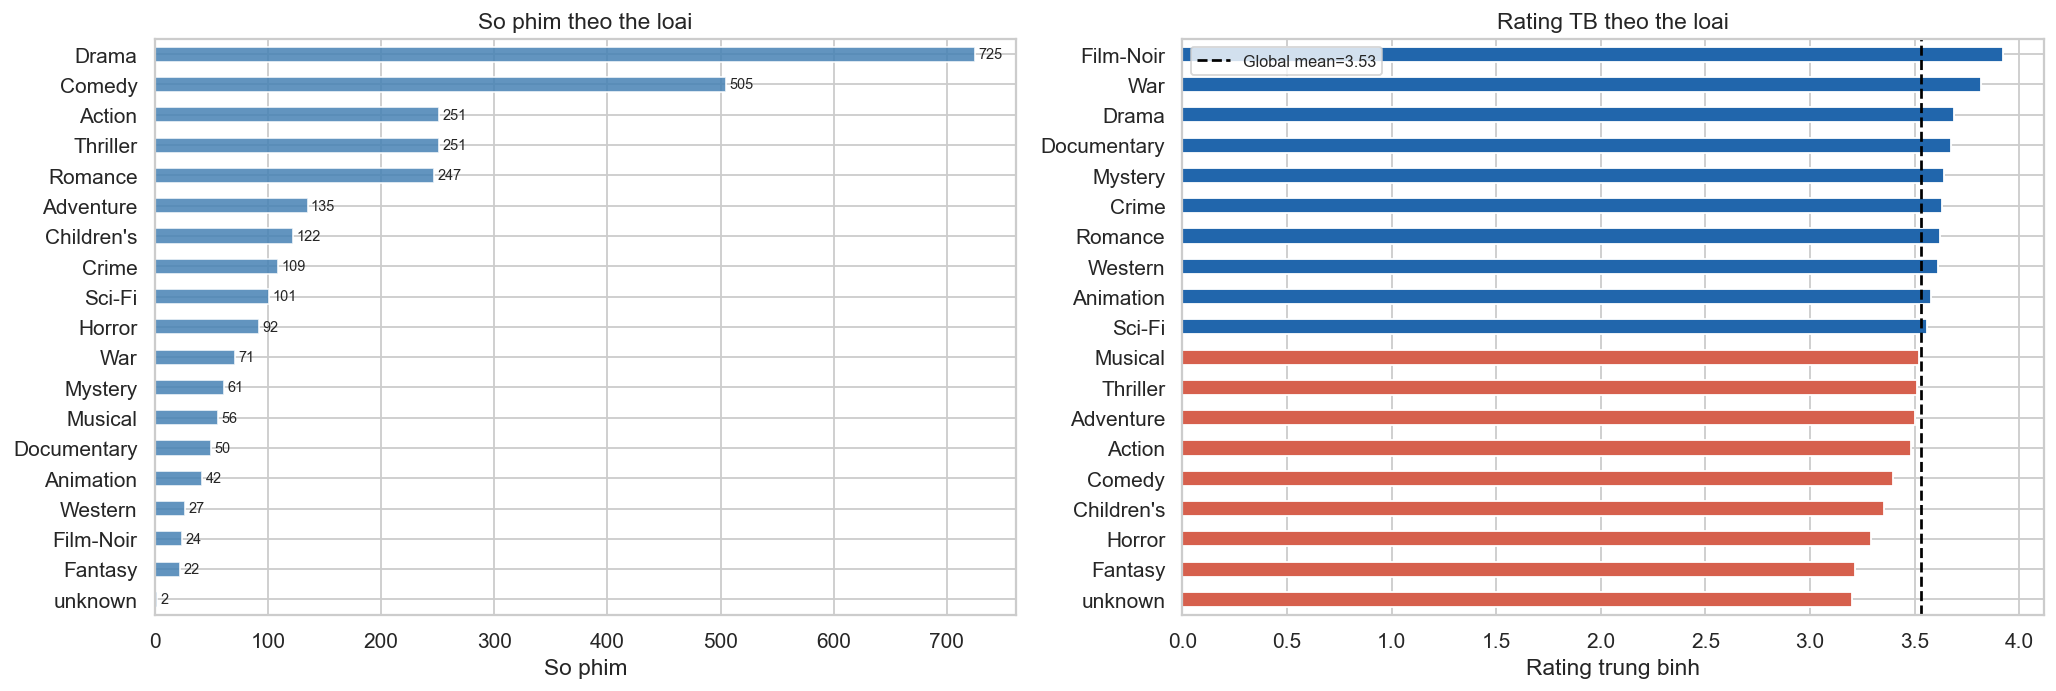

Top 5 pho bien: {'Drama': 725, 'Comedy': 505, 'Action': 251, 'Thriller': 251, 'Romance': 247}
Rating cao nhat: {'Film-Noir': 3.9215233698788228, 'War': 3.815811874866993, 'Drama': 3.6873793708484772}


In [34]:
genre_movie_count = movies[GENRE_COLS].sum().sort_values(ascending=False)

genre_avg = {}
for g in GENRE_COLS:
    ids = movies.loc[movies[g] == 1, 'movie_id']
    genre_avg[g] = ratings.loc[ratings['movie_id'].isin(ids), 'rating'].mean()
genre_avg_s = pd.Series(genre_avg).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

genre_movie_count.sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('So phim')
axes[0].set_title('So phim theo the loai')

for i, v in enumerate(genre_movie_count.sort_values().values):
    axes[0].text(v + 3, i, str(int(v)), va='center', fontsize=8)

colors_g = ['#2166ac' if v >= global_mean else '#d6604d'
            for v in genre_avg_s.sort_values().values]
genre_avg_s.sort_values().plot(
    kind='barh', ax=axes[1], color=colors_g, edgecolor='white')
axes[1].axvline(global_mean, color='black', linestyle='--', lw=1.5,
                label=f'Global mean={global_mean:.2f}')
axes[1].set_xlabel('Rating trung binh')
axes[1].set_title('Rating TB theo the loai')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_genre_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 pho bien:', genre_movie_count.head().to_dict())
print('Rating cao nhat:', genre_avg_s.head(3).to_dict())

---
## 6. Nhân khẩu học (Demographics)

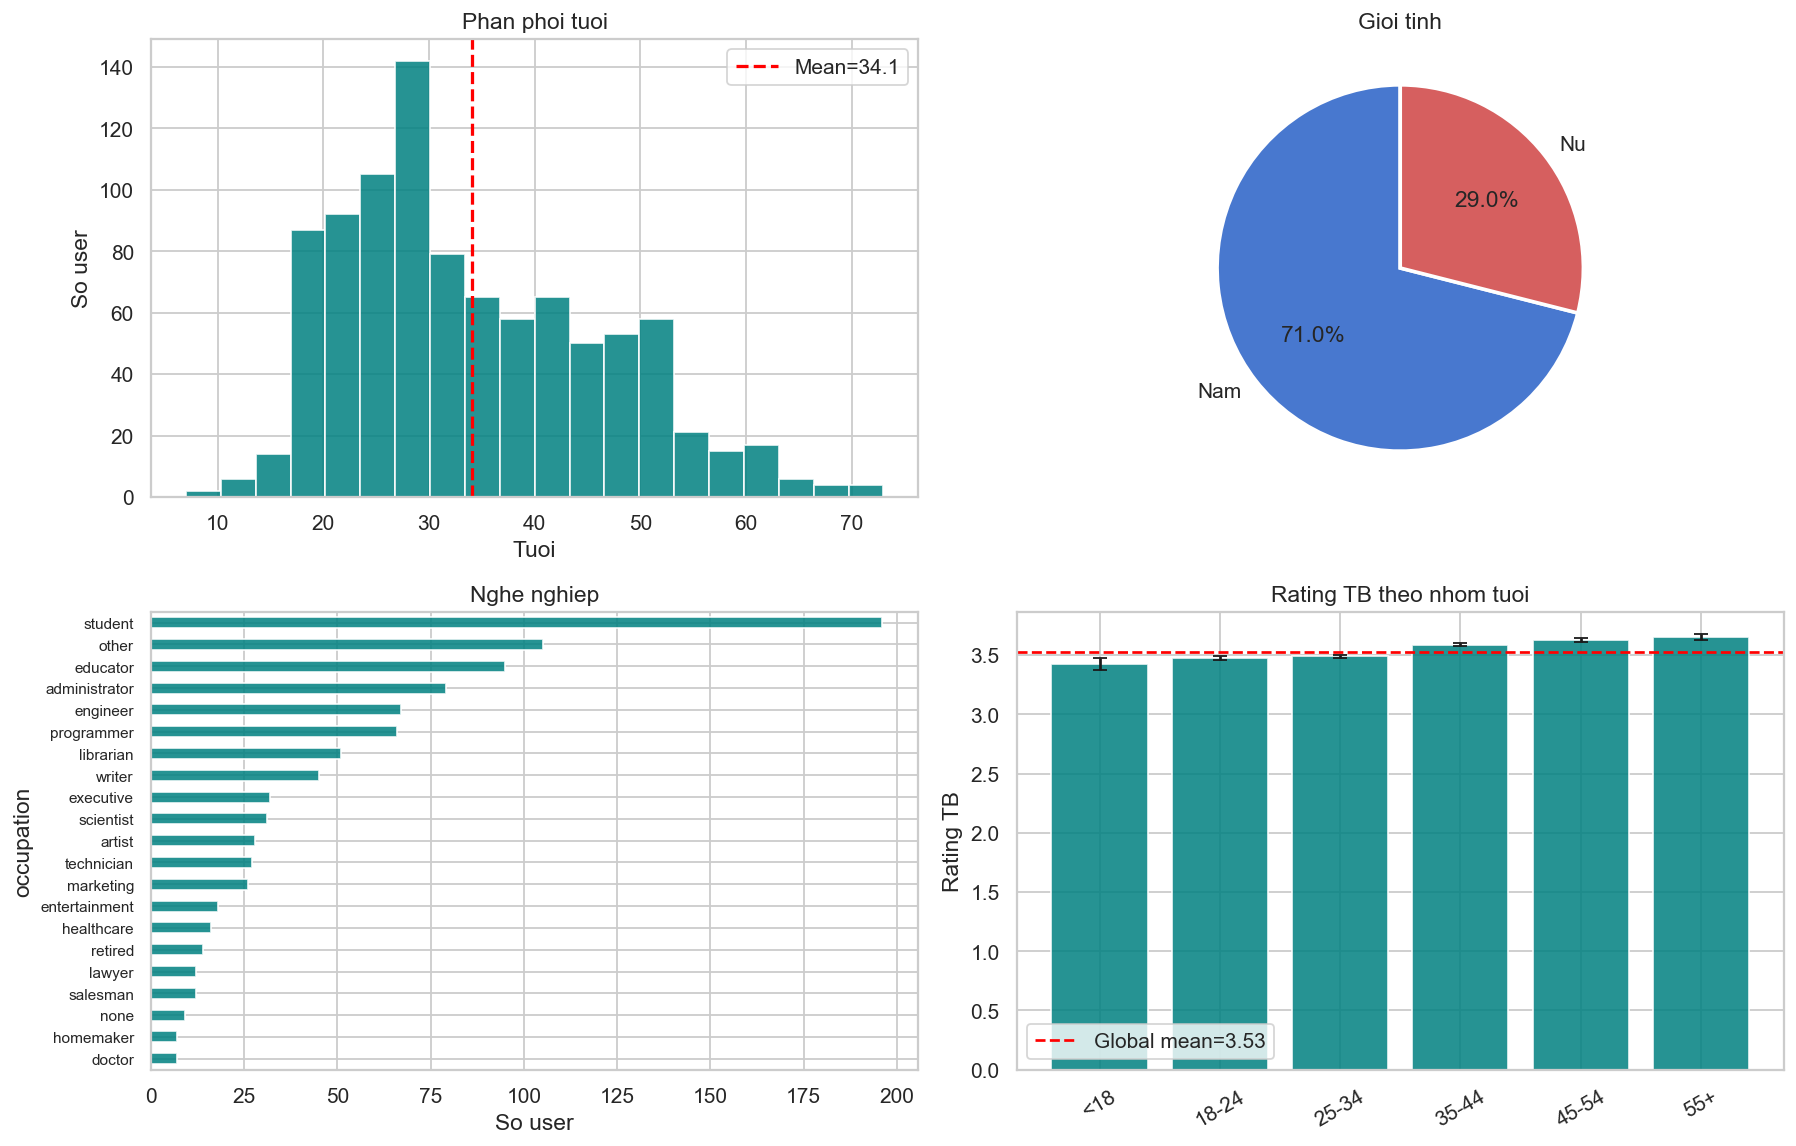

count    943.000000
mean      34.051962
std       12.192740
min        7.000000
25%       25.000000
50%       31.000000
75%       43.000000
max       73.000000

Gender: {'M': 670, 'F': 273}


In [35]:
age_bins   = [0, 18, 25, 35, 45, 55, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55+']
users_e = users.copy()
users_e['age_group'] = pd.cut(users_e['age'], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(users_e['age'], bins=20, color='teal', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(users_e['age'].mean(), color='red', linestyle='--', lw=1.8,
                   label=f'Mean={users_e["age"].mean():.1f}')
axes[0, 0].set_xlabel('Tuoi')
axes[0, 0].set_ylabel('So user')
axes[0, 0].set_title('Phan phoi tuoi')
axes[0, 0].legend()

gc = users_e['gender'].value_counts()
gender_names = ['Nam' if x == 'M' else 'Nu' for x in gc.index]
axes[0, 1].pie(gc.values, labels=gender_names, autopct='%1.1f%%',
               colors=['#4878CF', '#D65F5F'],
               startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 1].set_title('Gioi tinh')

users_e['occupation'].value_counts().sort_values().plot(
    kind='barh', ax=axes[1, 0], color='teal', edgecolor='white', alpha=0.85)
axes[1, 0].set_xlabel('So user')
axes[1, 0].set_title('Nghe nghiep')
axes[1, 0].tick_params(axis='y', labelsize=8.5)

ratings_age = ratings.merge(users_e[['user_id', 'age_group']], on='user_id', how='left')
age_stats = ratings_age.groupby('age_group')['rating'].agg(['mean', 'std', 'count'])
se = age_stats['std'] / np.sqrt(age_stats['count'])
axes[1, 1].bar(age_stats.index, age_stats['mean'],
               yerr=se * 1.96, color='teal', edgecolor='white', capsize=4, alpha=0.85)
axes[1, 1].axhline(global_mean, color='red', linestyle='--', lw=1.5,
                   label=f'Global mean={global_mean:.2f}')
axes[1, 1].set_ylabel('Rating TB')
axes[1, 1].set_title('Rating TB theo nhom tuoi')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(users_e['age'].describe().to_string())
print(f'\nGender: {gc.to_dict()}')

---
## 7. Ma trận Thưa (Sparsity)

Interaction matrix: (943, 1682)  |  sparsity = 94.93%


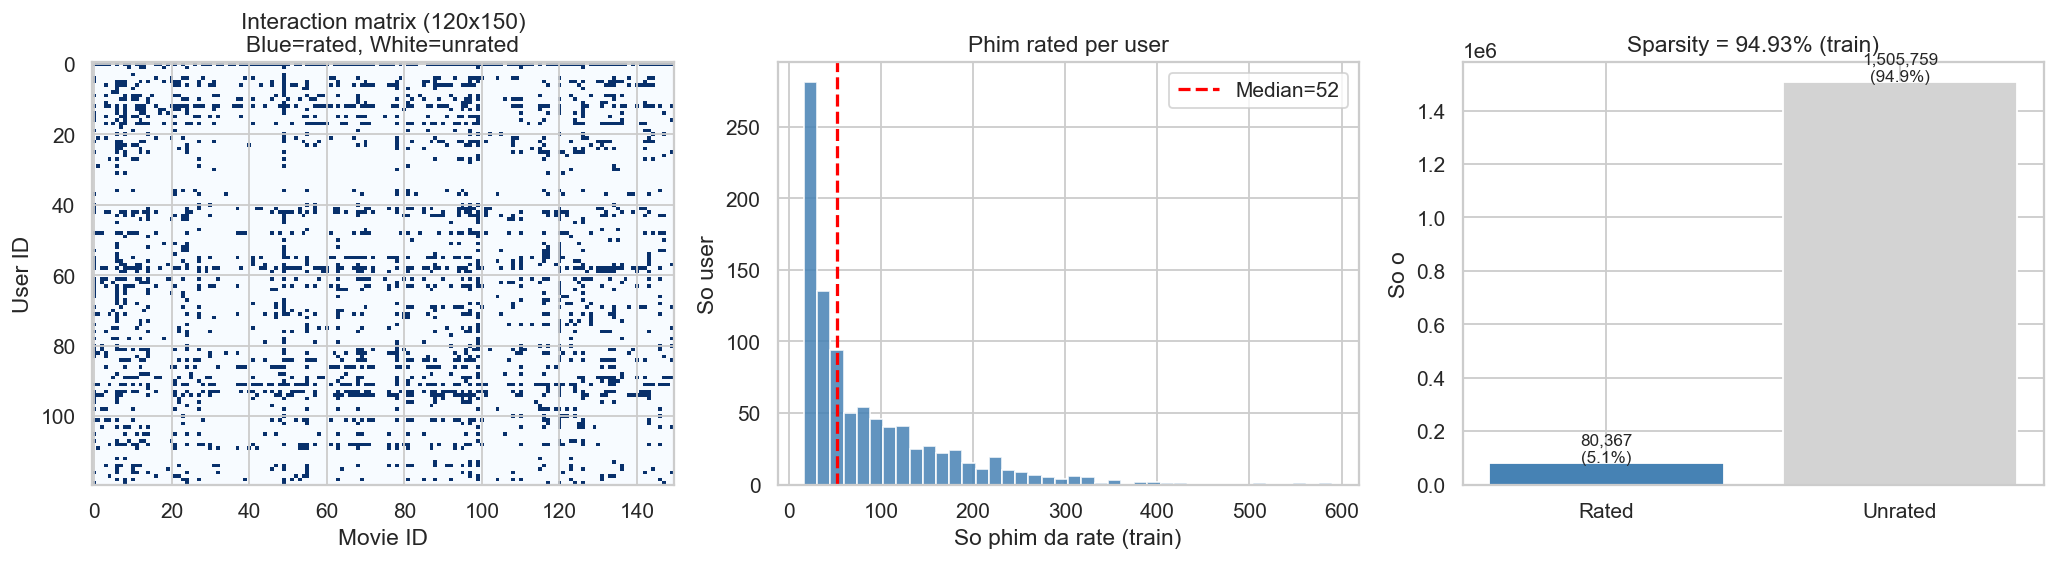

Matrix : (943, 1682)  |  sparsity (train) = 94.9331%
Mean films/user = 85.2  |  Median = 52


In [36]:
int_matrix = build_interaction_matrix(train_df)
train_sparsity = (int_matrix == 0).sum() / int_matrix.size

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].imshow(int_matrix[:120, :150] > 0, cmap='Blues', aspect='auto', interpolation='none')
axes[0].set_title('Interaction matrix (120x150)\nBlue=rated, White=unrated')
axes[0].set_xlabel('Movie ID')
axes[0].set_ylabel('User ID')

rated_per_user = (int_matrix > 0).sum(axis=1)
axes[1].hist(rated_per_user, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.median(rated_per_user), color='red', linestyle='--', lw=1.8,
                label=f'Median={np.median(rated_per_user):.0f}')
axes[1].set_xlabel('So phim da rate (train)')
axes[1].set_ylabel('So user')
axes[1].set_title('Phim rated per user')
axes[1].legend()

rated_n   = int((int_matrix > 0).sum())
unrated_n = int_matrix.size - rated_n
axes[2].bar(['Rated', 'Unrated'], [rated_n, unrated_n],
            color=['steelblue', '#D3D3D3'], edgecolor='white')
axes[2].set_ylabel('So o')
axes[2].set_title(f'Sparsity = {train_sparsity:.2%} (train)')
for i, v in enumerate([rated_n, unrated_n]):
    axes[2].text(i, v + 5000, f'{v:,}\n({v/int_matrix.size:.1%})', ha='center', fontsize=9.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_sparsity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrix : {int_matrix.shape}  |  sparsity (train) = {train_sparsity:.4%}')
print(f'Mean films/user = {rated_per_user.mean():.1f}  |  Median = {np.median(rated_per_user):.0f}')

---
## 8. Phân tích Thời gian (Temporal)

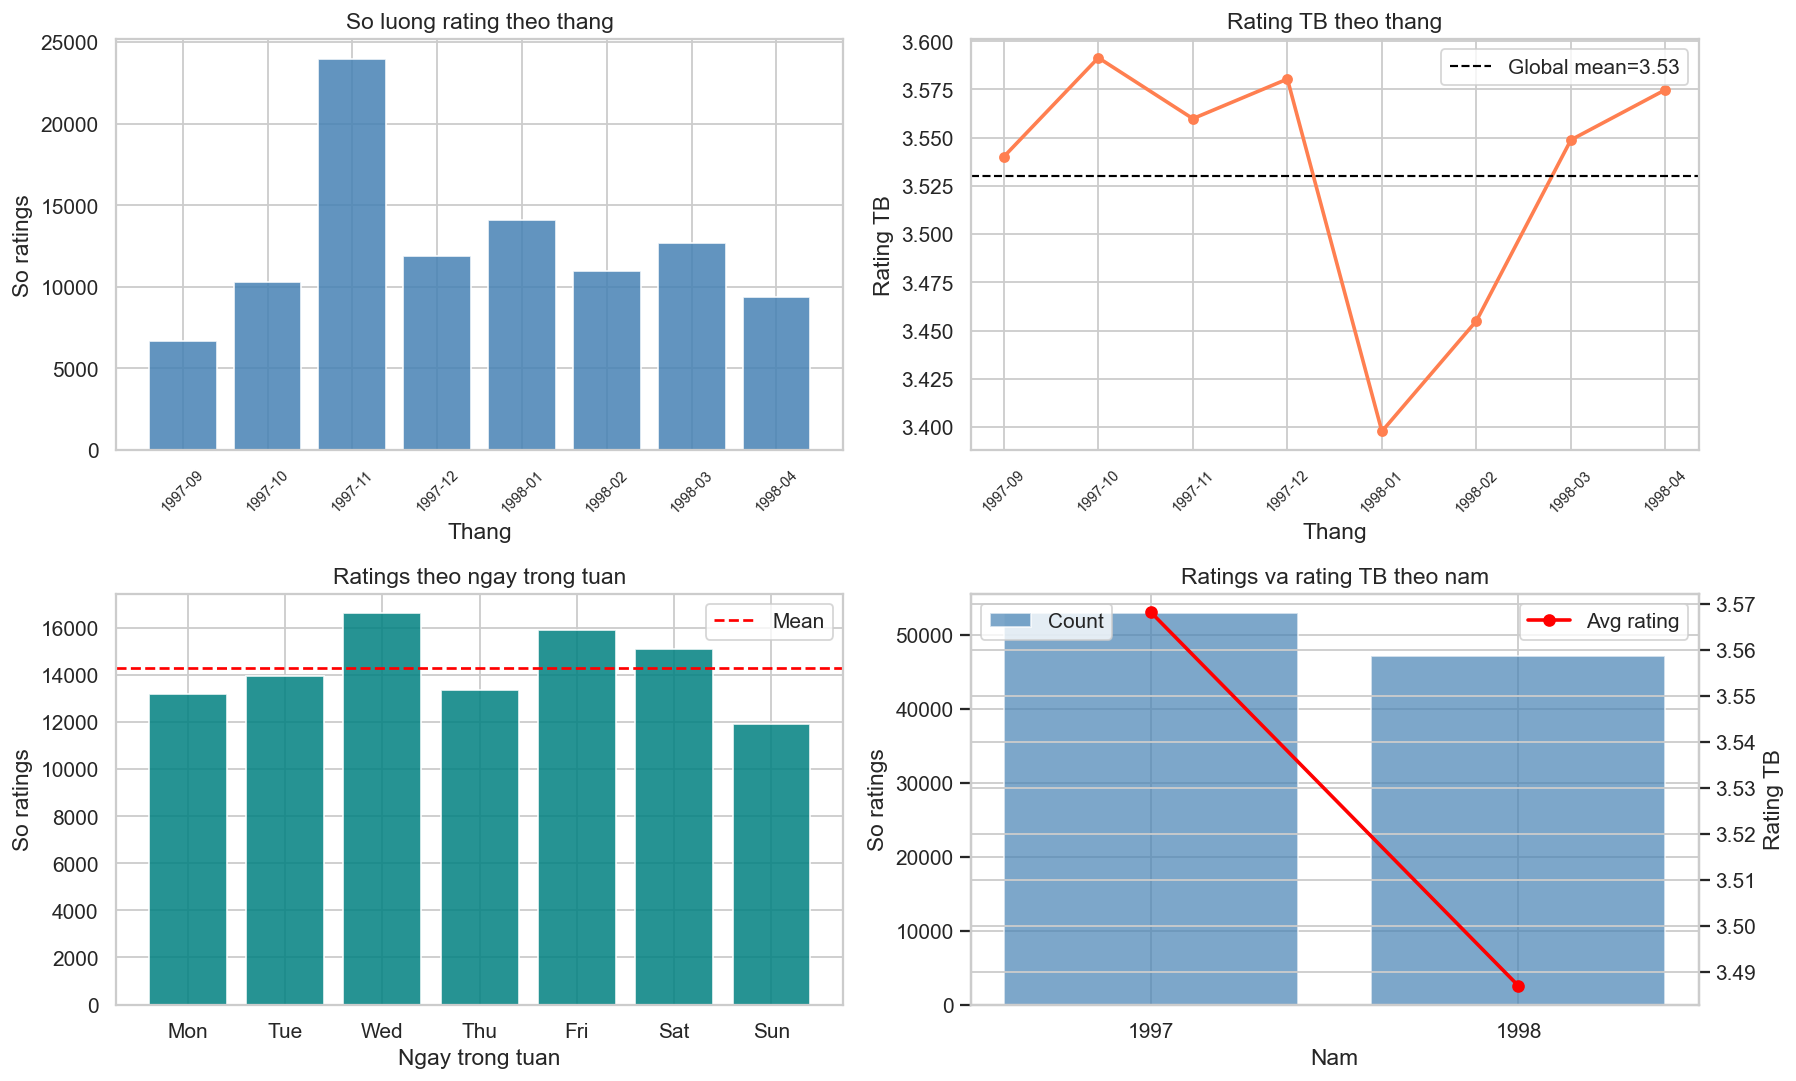

Khoang thoi gian: 1997-09-20 den 1998-04-22
Peak month: 1997-11  (23,980 ratings)


In [37]:
ratings_t = ratings.copy()
ratings_t['dt']         = pd.to_datetime(ratings_t['timestamp'], unit='s')
ratings_t['year_month'] = ratings_t['dt'].dt.to_period('M')
ratings_t['year_val']   = ratings_t['dt'].dt.year
ratings_t['dow']        = ratings_t['dt'].dt.dayofweek

monthly_count = ratings_t.groupby('year_month')['rating'].count()
monthly_avg   = ratings_t.groupby('year_month')['rating'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))

x_lbl = [str(p) for p in monthly_count.index]
axes[0, 0].bar(x_lbl, monthly_count.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_xlabel('Thang')
axes[0, 0].set_ylabel('So ratings')
axes[0, 0].set_title('So luong rating theo thang')
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8)

axes[0, 1].plot(x_lbl, monthly_avg.values, color='coral', lw=2, marker='o', ms=5)
axes[0, 1].axhline(global_mean, color='black', linestyle='--', lw=1.2,
                   label=f'Global mean={global_mean:.2f}')
axes[0, 1].set_xlabel('Thang')
axes[0, 1].set_ylabel('Rating TB')
axes[0, 1].set_title('Rating TB theo thang')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=8)
axes[0, 1].legend()

dow_counts = ratings_t.groupby('dow')['rating'].count()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(dow_labels, dow_counts.values, color='teal', edgecolor='white', alpha=0.85)
axes[1, 0].axhline(dow_counts.mean(), color='red', linestyle='--', lw=1.5, label='Mean')
axes[1, 0].set_xlabel('Ngay trong tuan')
axes[1, 0].set_ylabel('So ratings')
axes[1, 0].set_title('Ratings theo ngay trong tuan')
axes[1, 0].legend()

yearly = ratings_t.groupby('year_val')['rating'].agg(['count', 'mean'])
ax_r = axes[1, 1].twinx()
axes[1, 1].bar(yearly.index.astype(str), yearly['count'],
               color='steelblue', alpha=0.7, edgecolor='white', label='Count')
ax_r.plot(yearly.index.astype(str), yearly['mean'],
          color='red', lw=2, marker='o', ms=6, label='Avg rating')
axes[1, 1].set_xlabel('Nam')
axes[1, 1].set_ylabel('So ratings')
ax_r.set_ylabel('Rating TB')
axes[1, 1].set_title('Ratings va rating TB theo nam')
axes[1, 1].legend(loc='upper left')
ax_r.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Khoang thoi gian: {ratings_t["dt"].min().date()} den {ratings_t["dt"].max().date()}')
print(f'Peak month: {monthly_count.idxmax()}  ({monthly_count.max():,} ratings)')

---
## 9. Phân tích Chéo: Rating × Demographics × Genre

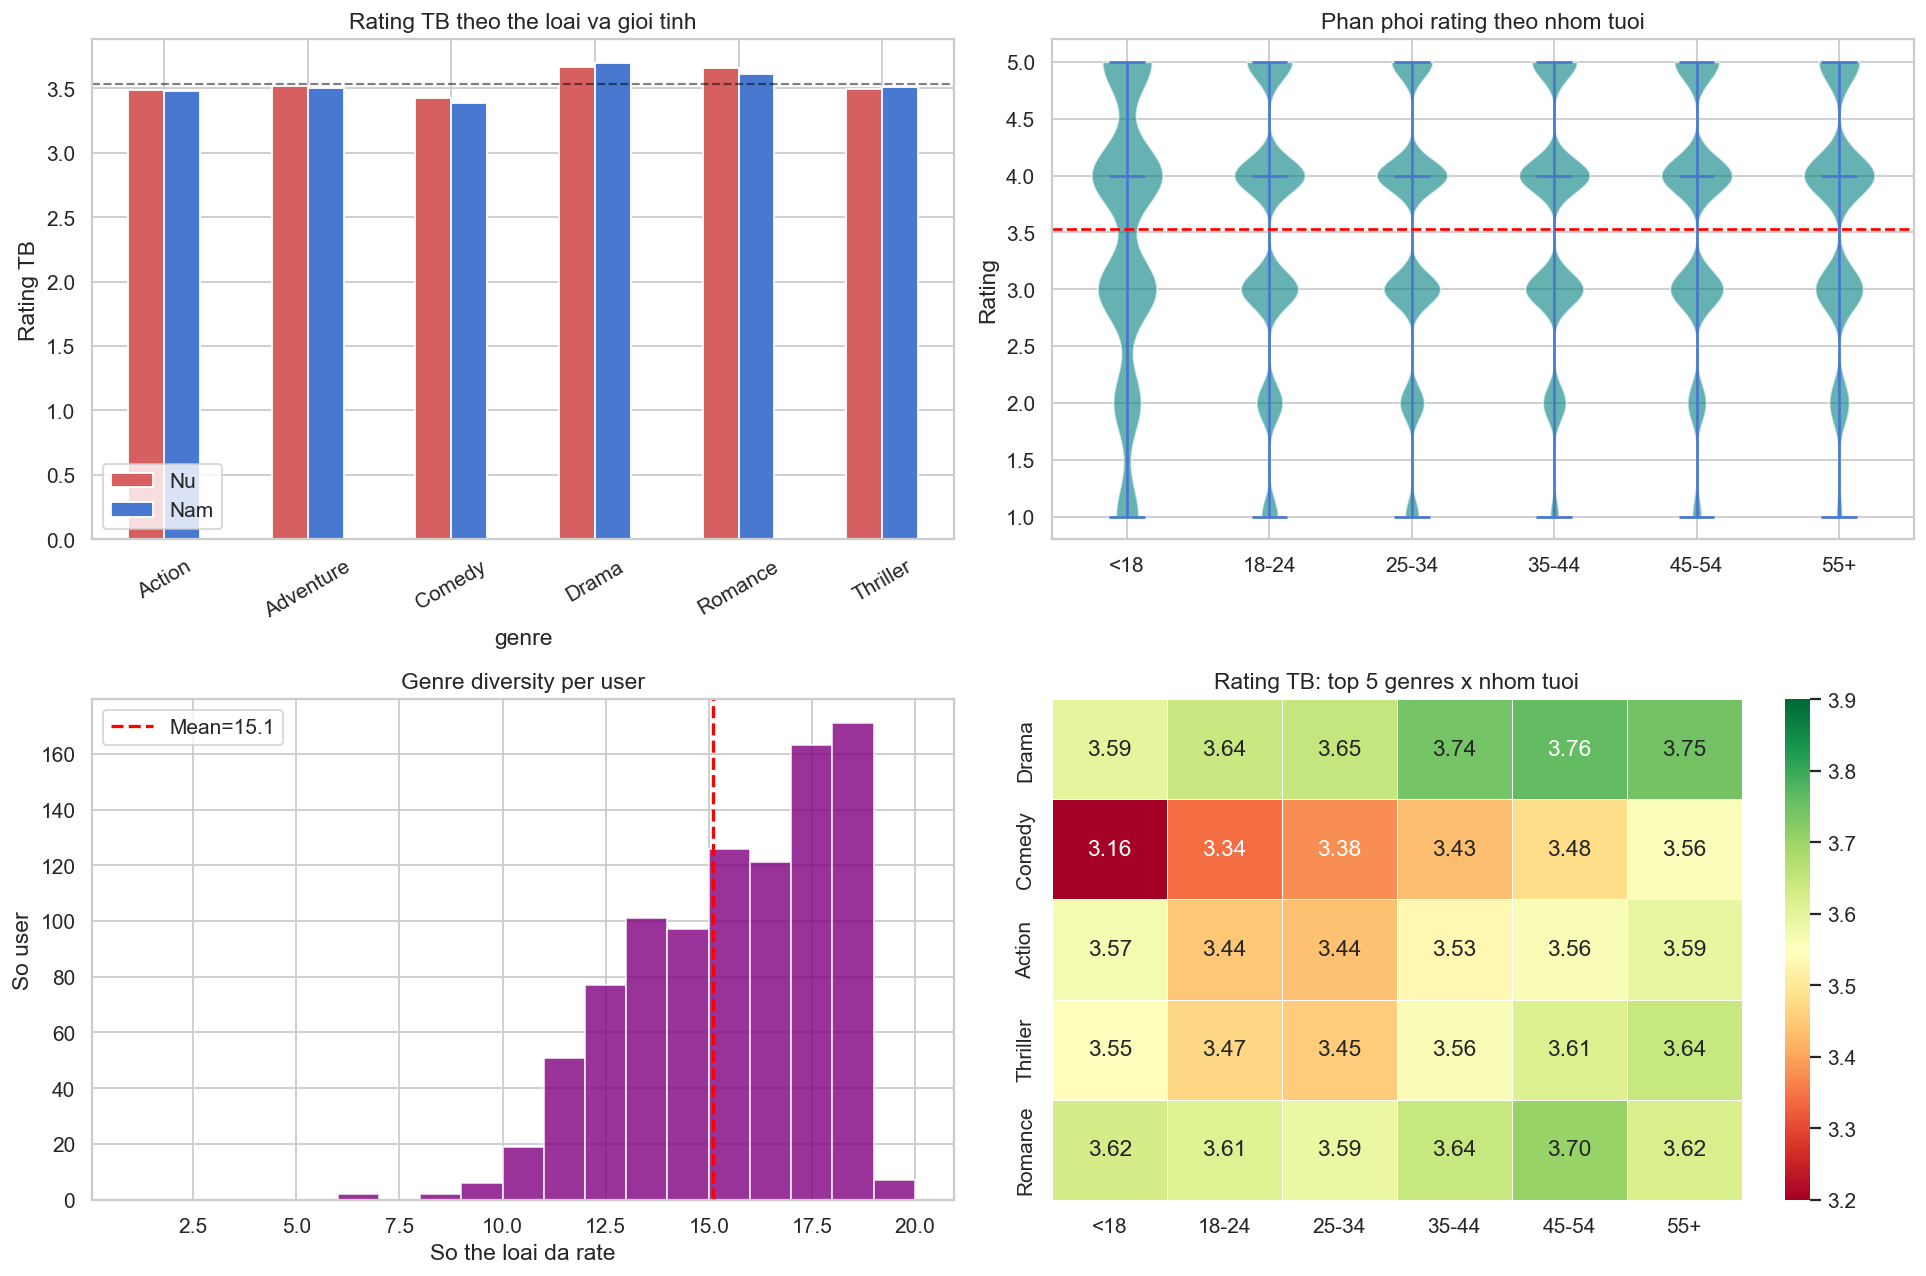

Genre diversity — Mean=15.1  Median=15  Min=6  Max=19


In [38]:
rat_demo  = ratings.merge(users_e[['user_id', 'gender', 'age', 'age_group']],
                          on='user_id', how='left')
rat_genre = rat_demo.merge(movies[['movie_id'] + GENRE_COLS], on='movie_id', how='left')
top_genres = movies[GENRE_COLS].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender x Genre
gg_rows = []
for g in top_genres:
    for gender in ['M', 'F']:
        mask = (rat_genre[g] == 1) & (rat_genre['gender'] == gender)
        if mask.sum() > 20:
            gg_rows.append({'genre': g, 'gender': gender,
                            'avg': rat_genre.loc[mask, 'rating'].mean()})
gg_df = pd.DataFrame(gg_rows)
if not gg_df.empty:
    gg_pivot = gg_df.pivot(index='genre', columns='gender', values='avg')
    gg_pivot.columns = ['Nu' if c == 'F' else 'Nam' for c in gg_pivot.columns]
    gg_pivot.plot(kind='bar', ax=axes[0, 0],
                  color=['#D65F5F', '#4878CF'], edgecolor='white', rot=30)
    axes[0, 0].axhline(global_mean, color='black', linestyle='--', lw=1.2, alpha=0.5)
axes[0, 0].set_ylabel('Rating TB')
axes[0, 0].set_title('Rating TB theo the loai va gioi tinh')

# Age group violin
age_order = [l for l in age_labels if l in rat_demo['age_group'].cat.categories]
ag_data = [rat_demo.loc[rat_demo['age_group'] == ag, 'rating'].values for ag in age_order]
vparts = axes[0, 1].violinplot(ag_data, positions=range(len(age_order)),
                                showmedians=True, showmeans=False)
for pc in vparts['bodies']:
    pc.set_facecolor('teal')
    pc.set_alpha(0.6)
axes[0, 1].set_xticks(range(len(age_order)))
axes[0, 1].set_xticklabels(age_order)
axes[0, 1].axhline(global_mean, color='red', linestyle='--', lw=1.5)
axes[0, 1].set_ylabel('Rating')
axes[0, 1].set_title('Phan phoi rating theo nhom tuoi')

# Genre diversity
user_genre_div = rat_genre.groupby('user_id')[GENRE_COLS].any().sum(axis=1)
axes[1, 0].hist(user_genre_div.values, bins=range(1, 21),
                color='purple', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(user_genre_div.mean(), color='red', linestyle='--', lw=1.8,
                   label=f'Mean={user_genre_div.mean():.1f}')
axes[1, 0].set_xlabel('So the loai da rate')
axes[1, 0].set_ylabel('So user')
axes[1, 0].set_title('Genre diversity per user')
axes[1, 0].legend()

# Heatmap top5 genre x age
top5g = movies[GENRE_COLS].sum().nlargest(5).index.tolist()
hm_data = []
for g in top5g:
    row = []
    for ag in age_labels:
        mask = (rat_genre[g] == 1) & (rat_genre['age_group'] == ag)
        row.append(rat_genre.loc[mask, 'rating'].mean() if mask.sum() > 10 else np.nan)
    hm_data.append(row)
hm_df = pd.DataFrame(hm_data, index=top5g, columns=age_labels)
sns.heatmap(hm_df, ax=axes[1, 1], annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=3.2, vmax=3.9, linewidths=0.5, linecolor='white')
axes[1, 1].set_title('Rating TB: top 5 genres x nhom tuoi')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_cross_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Genre diversity — Mean={user_genre_div.mean():.1f}  '
      f'Median={user_genre_div.median():.0f}  '
      f'Min={user_genre_div.min()}  Max={user_genre_div.max()}')

---
## 10. Feature Engineering — Build & Save Feature Matrices

| File | Shape |
|------|-------|
| `interaction_matrix.npy` | (943, 1682) |
| `user_features.npy` | (943, ~46) |
| `movie_features.npy` | (1682, ~28) |
| `user_latent.npy` | (943, 50) |
| `movie_latent.npy` | (1682, 50) |

In [39]:
feat = build_and_save_all(
    train_ratings=train_df,
    test_ratings=test_df,
    ratings=ratings,
    movies=movies,
    users=users,
    out_dir=FEAT_DIR
)

print('\n-- Files --')
for fname in ['interaction_matrix.npy', 'user_features.npy', 'movie_features.npy',
              'user_latent.npy', 'movie_latent.npy', 'train_ratings.csv', 'test_ratings.csv']:
    fpath = os.path.join(FEAT_DIR, fname)
    size  = os.path.getsize(fpath) / 1024 if os.path.isfile(fpath) else 0
    status = 'OK' if os.path.isfile(fpath) else 'MISSING'
    print(f'  [{status}]  {fname:<32}  {size:>8.1f} KB')

1/4  Interaction matrix...
Interaction matrix: (943, 1682)  |  sparsity = 94.93%

2/4  User features...
user_features: (943, 49)  |  49 features

3/4  Movie features...
movie_features: (1682, 27)  |  27 features

4/4  CF latent features (SVD k=50)...
user_factors : (943, 50)
movie_factors: (1682, 50)

✅ Saved to 'c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features/':
  interaction_matrix.npy         (943, 1682)
  user_features.npy              (943, 49)
  movie_features.npy             (1682, 27)
  user_latent.npy                (943, 50)
  movie_latent.npy               (1682, 50)

-- Files --
  [OK]  interaction_matrix.npy              6195.9 KB
  [OK]  user_features.npy                    180.6 KB
  [OK]  movie_features.npy                   177.5 KB
  [OK]  user_latent.npy                      184.3 KB
  [OK]  movie_latent.npy                     328.6 KB
  [OK]  train_ratings.csv                   1788.9 KB
  [OK]  test_ratings.csv                     436.9 KB


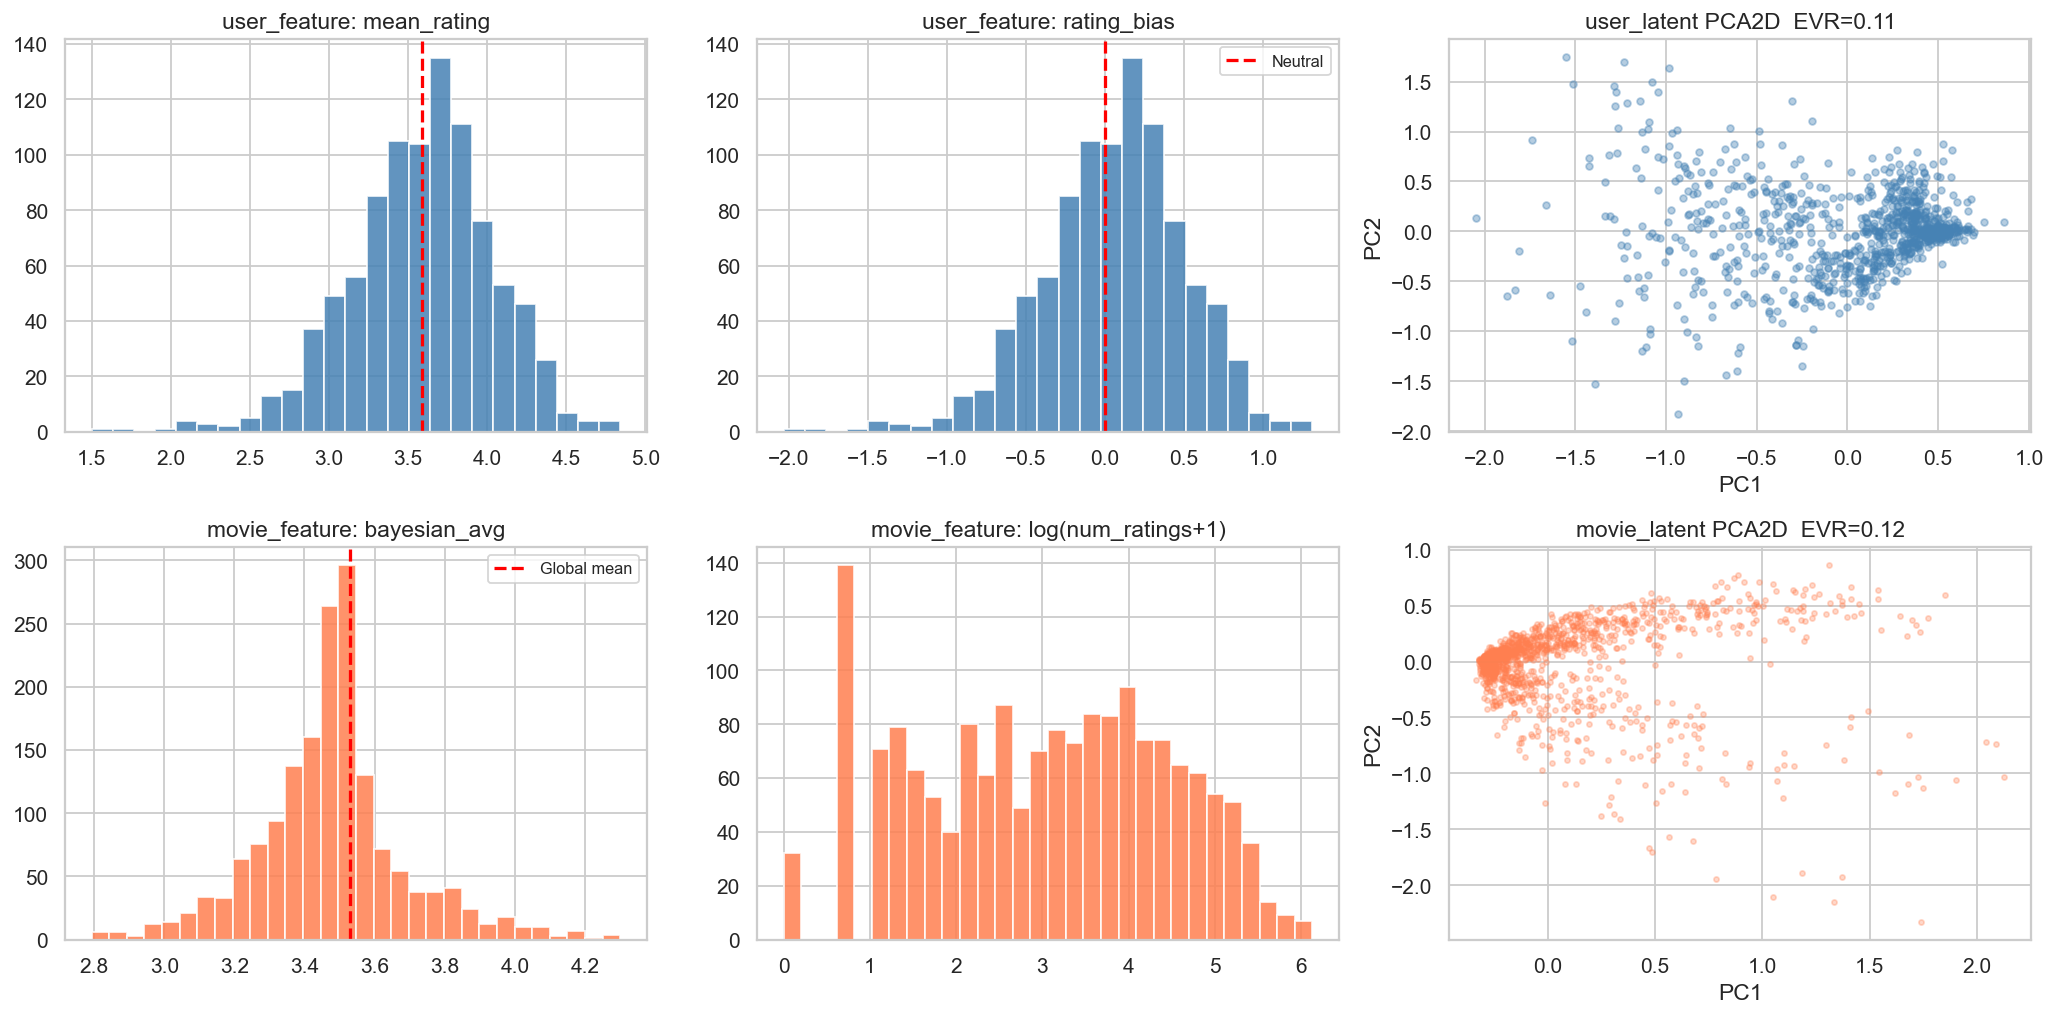

user_features  : (943, 49)  | 49 features
movie_features : (1682, 27)  | 27 features
user_latent    : (943, 50)
movie_latent   : (1682, 50)

User features  : ['age', 'gender_binary', 'occ_administrator', 'occ_artist', 'occ_doctor', 'occ_educator', 'occ_engineer', 'occ_entertainment', 'occ_executive', 'occ_healthcare', 'occ_homemaker', 'occ_lawyer', 'occ_librarian', 'occ_marketing', 'occ_none', 'occ_other', 'occ_programmer', 'occ_retired', 'occ_salesman', 'occ_scientist', 'occ_student', 'occ_technician', 'occ_writer', 'mean_rating', 'rating_std', 'num_ratings', 'rating_bias', 'active_days', 'pref_unknown', 'pref_Action', 'pref_Adventure', 'pref_Animation', "pref_Children's", 'pref_Comedy', 'pref_Crime', 'pref_Documentary', 'pref_Drama', 'pref_Fantasy', 'pref_Film-Noir', 'pref_Horror', 'pref_Musical', 'pref_Mystery', 'pref_Romance', 'pref_Sci-Fi', 'pref_Thriller', 'pref_War', 'pref_Western', 'genre_entropy', 'genre_count_rated']

Movie features : ['unknown', 'Action', 'Adventure', 'Anima

In [40]:
from sklearn.decomposition import PCA

uf, uf_names = feat['user_features'], feat['user_feat_names']
mf, mf_names = feat['movie_features'], feat['movie_feat_names']
ul, ml       = feat['user_factors'], feat['movie_factors']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

mr_idx = uf_names.index('mean_rating') if 'mean_rating' in uf_names else 0
axes[0, 0].hist(uf[:, mr_idx], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(float(np.mean(uf[:, mr_idx])), color='red', linestyle='--', lw=1.8)
axes[0, 0].set_title('user_feature: mean_rating')

rb_idx = uf_names.index('rating_bias') if 'rating_bias' in uf_names else 1
axes[0, 1].hist(uf[:, rb_idx], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color='red', linestyle='--', lw=1.8, label='Neutral')
axes[0, 1].set_title('user_feature: rating_bias')
axes[0, 1].legend(fontsize=9)

pca_u = PCA(n_components=2, random_state=42)
ul_2d = pca_u.fit_transform(ul)
axes[0, 2].scatter(ul_2d[:, 0], ul_2d[:, 1], alpha=0.4, s=14, c='steelblue')
axes[0, 2].set_title(f'user_latent PCA2D  EVR={pca_u.explained_variance_ratio_.sum():.2f}')
axes[0, 2].set_xlabel('PC1')
axes[0, 2].set_ylabel('PC2')

ba_idx = mf_names.index('bayesian_avg') if 'bayesian_avg' in mf_names else 0
axes[1, 0].hist(mf[:, ba_idx], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(global_mean, color='red', linestyle='--', lw=1.8, label='Global mean')
axes[1, 0].set_title('movie_feature: bayesian_avg')
axes[1, 0].legend(fontsize=9)

nr_idx = mf_names.index('num_ratings') if 'num_ratings' in mf_names else 1
axes[1, 1].hist(np.log1p(mf[:, nr_idx]), bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('movie_feature: log(num_ratings+1)')

pca_m = PCA(n_components=2, random_state=42)
ml_2d = pca_m.fit_transform(ml)
axes[1, 2].scatter(ml_2d[:, 0], ml_2d[:, 1], alpha=0.3, s=8, c='coral')
axes[1, 2].set_title(f'movie_latent PCA2D  EVR={pca_m.explained_variance_ratio_.sum():.2f}')
axes[1, 2].set_xlabel('PC1')
axes[1, 2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_features.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'user_features  : {uf.shape}  | {len(uf_names)} features')
print(f'movie_features : {mf.shape}  | {len(mf_names)} features')
print(f'user_latent    : {ul.shape}')
print(f'movie_latent   : {ml.shape}')
print(f'\nUser features  : {uf_names}')
print(f'\nMovie features : {mf_names}')